In [1]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import aplpy

import pandas as pd
import sys
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch

sys.path.append("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/process_tools")
from cut_resize_tools import *
from Astronomy import *

In [2]:
rank_csv_path = glob.glob("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Bubble_Catalogue/rank_catalogue/MWP_Rank*.csv")
rank_csv_path.sort()
rank_num = 1
rank_csv = pd.read_csv(rank_csv_path[rank_num])

In [3]:
# 1. カタログの読み込みとバブルの境界領域の計算
df = rank_csv

# Reff（有効半径）が分角(arcmin)であると仮定し、度に変換して境界を計算
# cutting_ratio = 2 に相当する幅（半径の2倍）を確保して矩形を定義します
cutting_ratio = 2
df['radius_deg'] = (df['Reff']/60) * cutting_ratio 

df['glon_min'] = df['GLON'] - df['radius_deg']
df['glon_max'] = df['GLON'] + df['radius_deg']
df['glat_min'] = df['GLAT'] - df['radius_deg']
df['glat_max'] = df['GLAT'] + df['radius_deg']

# 処理完了を管理するフラグと合計強度の格納列を追加
df['processed'] = False
df['total_intensity'] = np.nan

In [4]:
# 2. FITSファイルのリストを取得
fits_files = glob.glob("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/*.fits")
fits_files.sort()
integ_fits_files = glob.glob("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/FUGIN/mom0/FGN_*_2x2_12CO_v1.00_cube.pk_vsmooth_2.0_xysmooth_2.0_thresh_700.0_sigma_3.0_mom0.fits")
integ_fits_files.sort()

In [5]:
#使用速度幅の半分の値
width_half = 30

for i, fits_file in enumerate(fits_files):
    # まだ処理されていないバブルを抽出
    pending_bubbles = df[~df['processed']]
    if pending_bubbles.empty:
        break # 全てのバブルの処理が完了した場合は終了

    with fits.open(fits_file) as hdul:
        data = hdul[0].data
        cube_header = hdul[0].header
        cube_wcs = WCS(cube_header)

    integ_fits = integ_fits_files[i]
    with fits.open(integ_fits) as hdui:
        integ_header = hdui[0].header
        wcs = WCS(integ_header)

        # 3次元データ (Velocity, GLAT, GLON) の形状を取得
        n_y, n_x = data.shape[1:3]

        fits_l_min, fits_b_min = wcs.all_pix2world(n_x, 0, 0)
        fits_l_max, fits_b_max = wcs.all_pix2world(0, n_y, 0)
        
        # 現在のFITS領域内に完全に含まれるバブルを抽出
        contained = pending_bubbles[
            (pending_bubbles['glon_min'] >= fits_l_min) & 
            (pending_bubbles['glon_max'] <= fits_l_max) & 
            (pending_bubbles['glat_min'] >= fits_b_min) & 
            (pending_bubbles['glat_max'] <= fits_b_max)
        ]
        
        for idx, row in contained.iterrows():
            # バブルの矩形領域の最小・最大頂点をピクセル座標に変換
            world_coords = [
                [row['glon_min'], row['glat_min'], 0],
                [row['glon_max'], row['glat_max'], 0]
            ]
            pix_coords = cube_wcs.world_to_pixel_values(world_coords)
            
            x_coords = [p[0] for p in pix_coords]
            y_coords = [p[1] for p in pix_coords]
            
            # ピクセル座標を整数化し、画像範囲外にはみ出さないようクリップする
            x_min_pix = max(0, int(np.floor(min(x_coords))))
            x_max_pix = min(n_x, int(np.ceil(max(x_coords))))
            y_min_pix = max(0, int(np.floor(min(y_coords))))
            y_max_pix = min(n_y, int(np.ceil(max(y_coords))))
            
            # 全速度チャンネルを対象に3次元スライス
            cutting_data = data[:, y_min_pix:y_max_pix, x_min_pix:x_max_pix]
            mean = np.nanmean(cutting_data.copy(), axis=(1, 2))
            max_intens_v = np.argmax(mean)
            start_v = max_intens_v - width_half
            end_v = max_intens_v + width_half
            cutting_data = cutting_data[start_v:end_v, :, :]
            # print(cutting_data.shape)
            
            # 欠損値(NaN)を除外して合計強度を算出
            total_val = np.nansum(cutting_data)
            
            # 結果をデータフレームに記録し、処理済みとする
            df.at[idx, 'total_intensity'] = total_val
            df.at[idx, 'processed'] = True

In [6]:
df

,Unnamed: 0,MWP,GLON,GLAT,Disp,MajAxis,MinAxis,Reff,e_Reff,theta,...,Simbad,_RA.icrs,_DE.icrs,radius_deg,glon_min,glon_max,glat_min,glat_max,processed,total_intensity
0,2G3425472-0098003,2G3425472-0098003,342.5473,-0.9800,0.14,1.01,0.81,0.92,0.11,173,...,Simbad,255.0697,-43.8914,0.030667,342.516633,342.577967,-1.010667,-0.949333,False,NaN
1,2G3178410+0015146,2G3178410+0015146,317.8410,0.1515,0.75,1.30,0.93,1.13,0.34,42,...,Simbad,223.0074,-59.1841,0.037667,317.803333,317.878667,0.113833,0.189167,False,NaN
2,2G3200982+0074342,2G3200982+0074342,320.0982,0.7434,0.11,0.45,0.30,0.38,0.11,14,...,Simbad,226.2826,-57.6027,0.012667,320.085533,320.110867,0.730733,0.756067,False,NaN
3,2G3472593+0002260,2G3472593+0002260,347.2593,0.0226,0.54,0.65,0.46,0.56,0.17,45,...,Simbad,257.8119,-39.5299,0.018667,347.240633,347.277967,0.003933,0.041267,False,NaN
4,2G3479792-0046395,2G3479792-0046395,347.9792,-0.4640,0.53,2.18,1.58,1.90,0.30,47,...,Simbad,258.8682,-39.2325,0.063333,347.915867,348.042533,-0.527333,-0.400667,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,2G0195819-0023629,2G0195819-0023629,19.5819,-0.2363,1.43,1.50,0.90,1.23,0.57,14,...,Simbad,276.8972,-11.9686,0.041000,19.540900,19.622900,-0.277300,-0.195300,True,199885.234375
948,2G3555286-0010051,2G3555286-0010051,355.5287,-0.1005,0.32,1.57,1.18,1.39,0.18,8,...,Simbad,263.7380,-32.7787,0.046333,355.482367,355.575033,-0.146833,-0.054167,False,NaN
949,2G0307793+0023002,2G0307793+0023002,30.7793,0.2300,0.28,0.38,0.31,0.35,0.17,108,...,Simbad,281.6728,-1.8108,0.011667,30.767633,30.790967,0.218333,0.241667,True,43795.792969
950,2G3038689-0078639,2G3038689-0078639,303.8689,-0.7864,0.36,1.10,0.87,0.99,0.24,17,...,Simbad,194.9701,-63.6428,0.033000,303.835900,303.901900,-0.819400,-0.753400,False,NaN


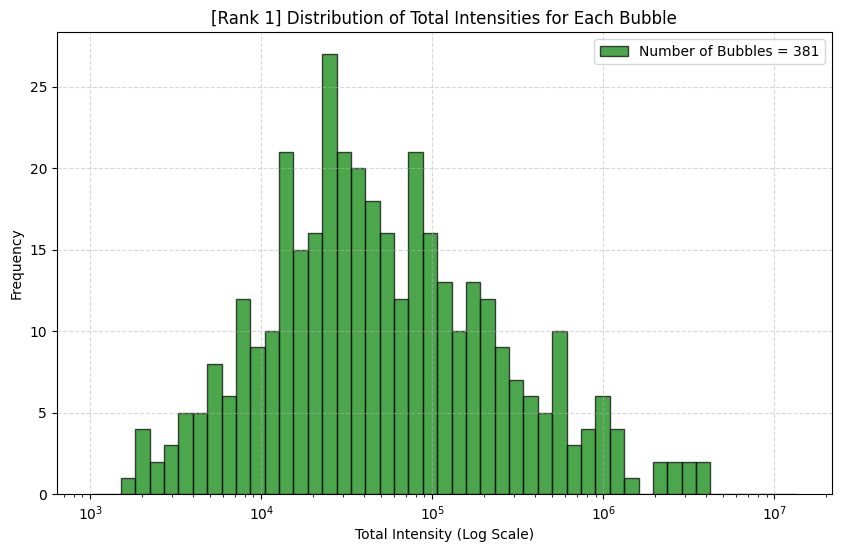

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
valid_intensities = df['total_intensity'].dropna()
positive_intensities = valid_intensities[valid_intensities > 0]

# データ数(N)を取得
N = len(positive_intensities)

min_val = positive_intensities.min()
max_val = positive_intensities.max()
log_bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)

# label引数で凡例用のテキスト（データ数）を指定
plt.hist(positive_intensities, bins=log_bins, color='green', alpha=0.7, edgecolor='black', label=f'Number of Bubbles = {N}')

plt.xscale('log')
plt.xlabel('Total Intensity (Log Scale)')
plt.ylabel('Frequency')
plt.title(f'[Rank {rank_num}] Distribution of Total Intensities for Each Bubble')
plt.grid(True, linestyle='--', alpha=0.5)

# 凡例を表示
plt.legend()
plt.savefig(f"[Rank{rank_num}]_Distribution_of_Total_Intensities_for_Each_Bubble")
plt.show()

In [13]:
true_count = df['processed'].sum()
print(true_count)

228
